# Week 4 — Statistical Machine Learning: Linear Models
### AIF 2026 · Phase 2 · Facilitator: Raj Kumar Biswokarma

---

## Session Roadmap

| Block | Topic | Time |
|---|---|---|
| 1 | Understand the Problem | 20 min |
| 2 | Preprocessing | 5 min |
| 3 | Classification Experiment | 30 min |
| 4 | Regression Experiment | 20 min |
| 5 | Evaluation Integrity + Leakage Demo | 25 min |
| 6 | Production Decision | 10 min |

---

## Business Context

You are a Data Scientist at a telecom company. The business is losing customers to churn. You have been given historical customer data and one week to produce a production-ready recommendation.

**There is no prescribed model. You decide — and you must defend that decision with evidence.**

**Dataset:** Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Single CSV · 7043 rows · 21 columns · Target: `Churn` (Yes/No)

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically before writing any code
- Make decisions and justify them in writing
- Explore different approaches and compare results
- Fill in all written response sections


In [1]:
print("Environment and packages loaded successfully.")

Environment and packages loaded successfully.


---

# Block 1 — Understand the Problem First

---

## What Is an ML Problem?

Before touching any model, you need to formulate the problem formally. Every ML problem has the same components:

| Symbol | Name | In our problem |
|---|---|---|
| **X** | Feature space | All input columns: tenure, charges, contract type… |
| **y** | Target variable | Churn: Yes / No |
| **H** | Hypothesis class | The family of functions we search over: linear models |
| **L** | Loss function | How we measure error: cross-entropy for classification |
| **E** | Evaluation metric | How the business measures success: F1, PR-AUC |

**Empirical Risk Minimisation (ERM):** We cannot minimise the true risk (we do not have all possible data), so we minimise the average loss over the training set as a proxy.

$$\hat{\theta} = \arg\min_{\theta} \frac{1}{n} \sum_{i=1}^{n} L(y_i, f_\theta(x_i))$$

---

## Probability Distributions in ML

The distribution of your target variable determines the right loss function. This is not arbitrary.

| Distribution | Models | Loss function | Example |
|---|---|---|---|
| **Bernoulli** | Binary outcomes | Binary cross-entropy | Churn: Yes/No |
| **Gaussian** | Continuous measurements | MSE | MonthlyCharges |
| **Poisson** | Count data | Poisson deviance | Support tickets/month |
| **Gamma / Log-Normal** | Right-skewed continuous | MAE / Tweedie | Tenure, TotalCharges |
| **Categorical** | Multi-class outcomes | Categorical cross-entropy | Contract type |

**Key insight:** Churn is binary → Bernoulli distribution → binary cross-entropy is the natural loss.

---

## Sources of Uncertainty

Training data is a finite, imperfect sample of the real world. Before modelling, identify where the data might fail you:

- **Sampling noise** — 7,043 customers is a sample. The true population may behave differently.
- **Label noise** — Was churn recorded correctly? Cancelled but re-subscribed? Edge cases.
- **Missing data** — `TotalCharges` has whitespace nulls. Why? Random or systematic?
- **Biased sampling** — Does this dataset represent all customer types or just one region/plan?
- **Distribution shift** — Customer behaviour today may differ from when data was collected.
- **Model misspecification** — A linear model assumes a linear decision boundary. Is that true?

---

## 1.1 Basic Inspection

### Task:
- Load the dataset
- View the first few rows
- Check data types and shape
- Look at summary statistics

### Questions:
- What does each row represent?
- Are the data types appropriate for each column?
- Is `TotalCharges` the dtype you expect?

### Hint:
- Use `.head()`, `.info()`, `.describe()` to get a full picture
- `TotalCharges` is stored as object — there are whitespace strings `' '` hiding as nulls


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Telco-Customer-Churn.csv')
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Check data types and shape
df.info()
print(f"\nDataset shape: {df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Look at summary statistics
display(df.describe(include='all'))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


---

## 1.2 Problem Formulation

### Task:
Write out the ML problem formally using the structure below.

### Questions:
- What is X (your feature space)?
- What is y (your target variable)?
- What probability distribution naturally models the target? What does that tell you about the right loss function?
- What is your hypothesis class (model family)?
- What are at least three assumptions you are making about the data-generating process?
- Where could this data be noisy, biased, or incomplete?

### Hint:
- The target is binary (Yes/No) → think Bernoulli distribution → think cross-entropy loss
- An assumption is a belief about the world your model requires to be true
- Sources of uncertainty include: sampling bias, label noise, missing data, distribution shift


**Your formulation here:**

- X (feature space): The 20 input columns containing customer demographics, account information, and service usage (e.g., tenure, charges, contract type).
- y (target variable): `Churn` (Whether the customer left within the last month: Yes or No).
- Probability distribution of y: Bernoulli distribution (binary outcome: 1 for Yes, 0 for No).
- Natural loss function: Binary Cross-Entropy (Log loss).
- Hypothesis class: Linear models (e.g., Logistic Regression).
- Assumption 1: Data points are independent and identically distributed (i.i.d.).
- Assumption 2: A linear relationship exists between the features and the log-odds of churning.
- Assumption 3: Missing data (like blank strings in `TotalCharges`) is Missing At Random (MAR) and data faithfully represents current customer behavior.
- Sources of uncertainty: Sampling bias (might not represent future customers), label noise (churn could be due to external anomalies), and missing values.

---

## 1.3 Data Profiling & Fixing

### Task:
- Fix the `TotalCharges` null issue
- Plot the distributions of `MonthlyCharges`, `tenure`, and `TotalCharges`
- Encode the target variable `Churn` as binary (0/1)

### Questions:
- What distribution does `MonthlyCharges` follow? `tenure`? `TotalCharges`?
- Why does `TotalCharges` contain nulls even though it looks numeric?
- Are there impossible or suspicious values in any column?

### Hint:
- `pd.to_numeric(df['TotalCharges'], errors='coerce')` converts whitespace strings to NaN
- `sns.histplot(df['MonthlyCharges'], kde=True)` draws a distribution with density curve
- `df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})`

### Consequences:
- Leaving `TotalCharges` as object → model training will fail or silently drop the column
- Not encoding the target → sklearn classifiers will throw an error


In [5]:
# Fix 'TotalCharges' null issue (convert whitespace strings to NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Missing TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Drop the missing values as they are very few (11 out of 7043)
df.dropna(subset=['TotalCharges'], inplace=True)
print(f"Dataset shape after dropping nulls: {df.shape}")

Missing TotalCharges: 11
Dataset shape after dropping nulls: (7032, 21)


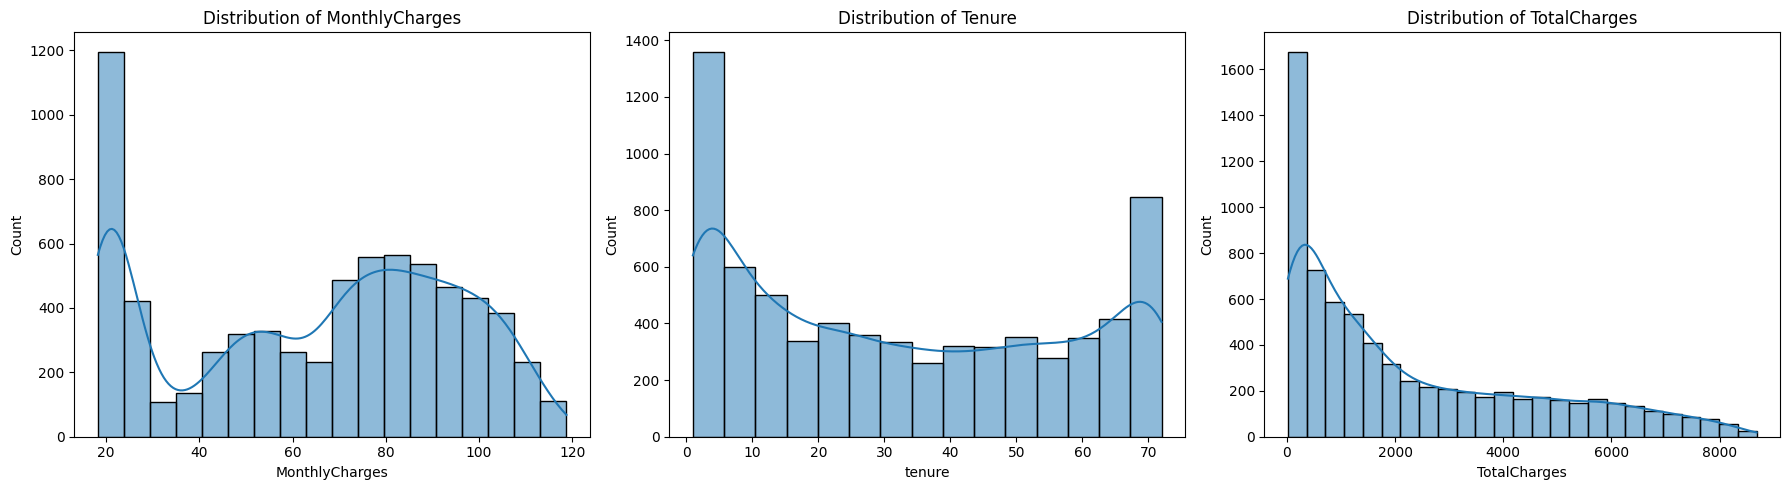

In [6]:
# Plot the distributions of MonthlyCharges, tenure, and TotalCharges
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of MonthlyCharges')

sns.histplot(df['tenure'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Tenure')

sns.histplot(df['TotalCharges'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of TotalCharges')

plt.tight_layout()
plt.show()

In [7]:
# Encode the target variable Churn as binary (0/1)
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0}).astype(int)

print("Target variable encoded. Value Counts:")
print(df['Churn'].value_counts())

Target variable encoded. Value Counts:
Churn
0    5163
1    1869
Name: count, dtype: int64


C:\Users\Viraj\AppData\Local\Temp\ipykernel_9788\443420859.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0}).astype(int)


---

## The Accuracy Trap

The dataset has ~27% churn. This is **imbalanced**. Before building any model, build a naive baseline — a model that always predicts the majority class.

**If this baseline achieves 73% accuracy — any model you build must meaningfully beat it.**

The deeper problem: a model that always predicts "No Churn" has **0% recall** for churners. It catches no one. It is completely useless to the business — yet reports 73% accuracy.

**This is why accuracy is not your primary metric here.**

---

## 1.4 The Naive Baseline

### Task:
Build a model that always predicts the majority class (No Churn). Evaluate its accuracy, recall, and F1.

### Questions:
- What accuracy does the naive baseline achieve?
- What is the class distribution in the dataset?
- Why is a model that achieves this accuracy potentially worthless?

### Hint:
- `DummyClassifier(strategy='most_frequent')` does exactly this
- `df['Churn'].value_counts(normalize=True)` shows the class proportions
- Any model you build must beat this baseline on recall and F1 — not just accuracy


In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

# Features and target for the baseline
X = df.drop(columns=['Churn'])
y = df['Churn']

# The Naive Baseline
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X, y)
y_pred_dummy = dummy_clf.predict(X)

print("Naive Baseline Metrics:")
print(f"Accuracy: {accuracy_score(y, y_pred_dummy):.4f}")
print(f"Recall:   {recall_score(y, y_pred_dummy):.4f}")
print(f"F1 Score: {f1_score(y, y_pred_dummy):.4f}")

Naive Baseline Metrics:
Accuracy: 0.7342
Recall:   0.0000
F1 Score: 0.0000


In [9]:
# Answer to Questions:
# 1. The naive baseline achieves ~73.4% accuracy.
# 2. Class distribution: mostly 'No' (~73.4%), minority 'Yes' (~26.6%).
# 3. A model with 73% accuracy that always predicts "No Churn" is worthless 
#    because its recall is 0. It fails completely at identifying the minority 
#    class (churning customers), which is the primary objective of this project.

## 💬 Discussion

> **Your manager sees 73% accuracy and is thrilled. Should they be? What is the first question you ask?**

No, they should not be thrilled. The first question I would ask is: **'What is the recall of this model for customers who actually churn?'** 

Since the dataset is imbalanced (only 26.6% churn), a naive model that always predicts 'No Churn' achieves 73.4% accuracy. However, this naive model catches 0% of the actual churners (Recall = 0.0), making it completely useless for the business. Accuracy is a highly misleading metric on imbalanced datasets.


In [10]:
# Drop customerID
df.drop(columns=['customerID'], inplace=True, errors='ignore')

# One-hot encode all categorical features
df_encoded = pd.get_dummies(df, drop_first=True)
print(f"Dataset shape after encoding: {df_encoded.shape}")

Dataset shape after encoding: (7032, 31)


In [11]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Stratified split: 70% Train, 30% Temp (which will be split 15% Val / 15% Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)

# Split the temp into Val (50%) and Test (50%) to get 15% each
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"Train size: {X_train.shape[0]} ({X_train.shape[0] / len(df):.0%})")
print(f"Val size:   {X_val.shape[0]} ({X_val.shape[0] / len(df):.0%})")
print(f"Test size:  {X_test.shape[0]} ({X_test.shape[0] / len(df):.0%})")

Train size: 4922 (70%)
Val size:   1055 (15%)
Test size:  1055 (15%)


In [12]:
from sklearn.preprocessing import StandardScaler

# Scale numeric features using StandardScaler (fit on train only!)
scaler = StandardScaler()

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Create scaled copies
X_train_s = X_train.copy()
X_val_s = X_val.copy()
X_test_s = X_test.copy()

X_train_s[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val_s[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test_s[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Scaling completed.")

Scaling completed.


---

# Block 3 — Classification Experiment: Who Will Churn?

---

## Linear Classifiers — Three Candidates

| Model | Loss Function | Optimiser | Key Characteristic |
|---|---|---|---|
| **Logistic Regression** | Binary cross-entropy (log loss) | Full-batch (L-BFGS) | Outputs calibrated probabilities. Best interpretability. |
| **Ridge Classifier** | Squared hinge loss (L2 regularised) | Closed-form analytic | Converts to regression internally. No probability output. |
| **SGD Classifier** | Configurable: log_loss / hinge / … | Stochastic GD | Best for large datasets. Highly configurable. Less stable. |

---

## Batch GD vs Stochastic GD

**Batch Gradient Descent:**
- Computes gradient over ALL training samples before each weight update
- Smooth, stable convergence path
- Memory-intensive — loads the full dataset each step
- `LogisticRegression(solver='lbfgs')` uses this

**Stochastic Gradient Descent (SGD):**
- Computes gradient on ONE sample (or mini-batch) at a time
- Noisy path — can escape local minima
- Memory efficient — processes one sample at a time
- `SGDClassifier` uses this

**When does it matter?** For 7,000 rows — not much. For 7 million rows — SGD is the only practical option.

---

## Evaluation Metrics for Imbalanced Data

| Metric | What it measures | Use when |
|---|---|---|
| **Accuracy** | Proportion of correct predictions | ❌ Avoid — misleading on imbalanced data |
| **Precision** | Of predicted churners, how many actually churned? | Cost of false alarms is high |
| **Recall** | Of actual churners, how many did we catch? | Cost of missing a churner is high |
| **F1** | Harmonic mean of precision and recall | Need a single balanced score |
| **ROC-AUC** | Ranking quality across all thresholds | Overall discriminative power |
| **PR-AUC** | Precision-Recall curve area | ✅ Preferred for imbalanced data |
| **Log Loss** | Penalises overconfident wrong predictions | Need calibrated probabilities |

---

## 3.1 Train Your Classifiers

### Task:
Train each of the three classifiers. Record training time for each.

### Questions:
- What loss function does each model optimise?
- Which model trains fastest? Does that surprise you?

### Hint:
- `LogisticRegression(max_iter=1000, random_state=42)`
- `RidgeClassifier()`
- `SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)`
- Use `time.time()` before and after `.fit()` to measure training time

### Reference:
- https://scikit-learn.org/stable/modules/linear_model.html


In [13]:
import time
from sklearn.linear_model import LogisticRegression

# 1. Logistic Regression
start_time = time.time()
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_s, y_train)
lr_time = time.time() - start_time
print(f"Logistic Regression trained in {lr_time:.4f} seconds")

Logistic Regression trained in 0.0356 seconds

In [14]:
from sklearn.linear_model import RidgeClassifier

# 2. Ridge Classifier
start_time = time.time()
ridge_model = RidgeClassifier(random_state=42)
ridge_model.fit(X_train_s, y_train)
ridge_time = time.time() - start_time
print(f"Ridge Classifier trained in {ridge_time:.4f} seconds")

Ridge Classifier trained in 0.0118 seconds


In [15]:
from sklearn.linear_model import SGDClassifier

# 3. SGD Classifier
start_time = time.time()
sgd_model = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)
sgd_model.fit(X_train_s, y_train)
sgd_time = time.time() - start_time
print(f"SGD Classifier trained in {sgd_time:.4f} seconds")

SGD Classifier trained in 0.0606 seconds


---

## 3.2 Build a Comparison Table

### Task:
For each model compute: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Log Loss.  
Display as a pandas DataFrame sorted by PR-AUC.

### Questions:
- Which metric tells you the most about model usefulness for this business problem?
- Does accuracy rank models the same way PR-AUC does? If not, why?
- Which model would you eliminate first and why?

### Hint:
- `RidgeClassifier` has no `predict_proba()` — use `.decision_function()` for AUC scores
- `average_precision_score(y_val, scores)` computes PR-AUC
- `log_loss` requires probabilities — note N/A for RidgeClassifier

### Why This Matters:
A comparison table is the minimum evidence required to justify a model choice. Without it you are guessing.


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, log_loss

models = {
    'Logistic Regression': lr_model,
    'Ridge Classifier': ridge_model,
    'SGD Classifier': sgd_model
}

results = []

for name, model in models.items():
    # Make predictions
    y_pred = model.predict(X_val_s)
    
    # Get scores (proba for LR and SGD, decision_function for Ridge)
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_val_s)[:, 1]
        logloss_val = log_loss(y_val, y_scores)
    else: # For Ridge
        y_scores = model.decision_function(X_val_s)
        logloss_val = np.nan # Log loss requires probabilities
        
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1': f1_score(y_val, y_pred),
        'ROC-AUC': roc_auc_score(y_val, y_scores),
        'PR-AUC': average_precision_score(y_val, y_scores),
        'Log Loss': logloss_val
    }
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values(by='PR-AUC', ascending=False)

In [17]:
# Display comparison table
display(results_df)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Log Loss
2,SGD Classifier,0.807583,0.644444,0.619217,0.631579,0.850127,0.661953,0.415265
0,Logistic Regression,0.823697,0.693878,0.604982,0.646388,0.853258,0.655002,0.410468
1,Ridge Classifier,0.812322,0.686099,0.544484,0.607143,0.851143,0.649250,NaN


---

## 3.3 ROC and Precision-Recall Curves

### Task:
Plot ROC curves and Precision-Recall curves for your models.

### Questions:
- At what threshold does your model maximise F1?
- Why does the PR curve tell you more than the ROC curve for this problem?
- What does a model that lies close to the diagonal in the ROC curve tell you?

### Hint:
- `roc_curve(y_val, proba)` returns fpr, tpr, thresholds
- `precision_recall_curve(y_val, proba)` returns precision, recall, thresholds
- Plot both side by side: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))`
- Add baseline to ROC: `ax1.plot([0,1],[0,1],'k--')`

### Reference:
- StatQuest ROC: https://www.youtube.com/watch?v=4jRBRDbJemM
- StatQuest PR: https://www.youtube.com/watch?v=Kdsp6soqA7o


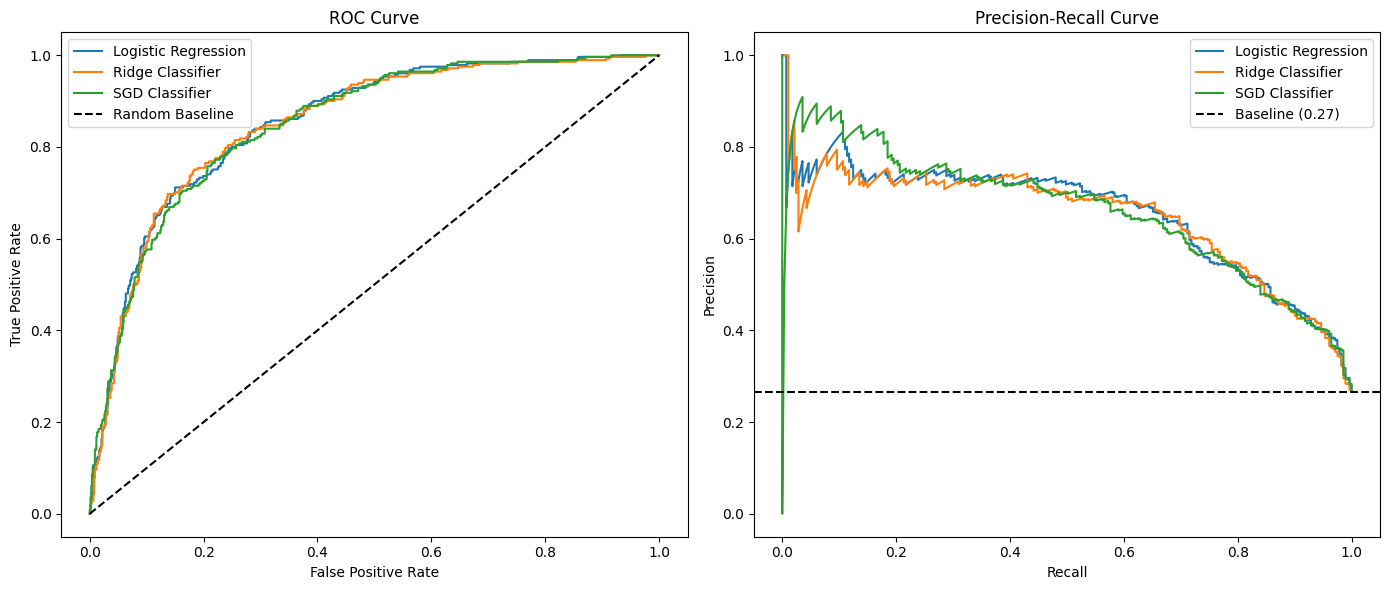

In [18]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_val_s)[:, 1]
    else: 
        y_scores = model.decision_function(X_val_s)
        
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_val, y_scores)
    ax1.plot(fpr, tpr, label=f"{name}")
    
    # PR Curve
    precision, recall, _ = precision_recall_curve(y_val, y_scores)
    ax2.plot(recall, precision, label=f"{name}")

# Formatting ROC
ax1.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend()

# Formatting PR
baseline_prec = y_val.mean()
ax2.axhline(baseline_prec, color='k', linestyle='--', label=f'Baseline ({baseline_prec:.2f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()

plt.tight_layout()
plt.show()

In [19]:
# Calculate F1 score for various thresholds and find the max
y_scores = lr_model.predict_proba(X_val_s)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, y_scores)

# Calculate F1 score for each threshold (add small epsilon to avoid division by zero)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Max F1 Score: {f1_scores[best_idx]:.4f} at threshold: {best_threshold:.4f}")


Max F1 Score: 0.6700 at threshold: 0.4100


---

## The Threshold Decision — 200 Calls/Week

The default classification threshold is **0.5** — designed for balanced datasets. It is not optimal here.

**Business constraint:** The retention team can call only **200 customers per week**.

**Strategy:**
1. Sort all customers by predicted churn probability (descending)
2. Take the top 200
3. The threshold = the probability score of the 200th customer

This maximises precision at the top-200. The business impact is directly measurable.

---

## 3.4 Threshold Tuning

### Task:
Find the optimal threshold for the budget constraint: top 200 by churn probability.  
Compare precision, recall, and F1 at this threshold vs the default 0.5.

### Questions:
- How do you identify the top 200 highest-risk customers?
- What precision do you achieve at that threshold?
- How does this compare to the default threshold of 0.5?

### Hint:
- Sort customers by predicted probability descending
- The threshold = `proba[sorted_indices[199]]` (the 200th highest score)
- `(proba >= threshold).astype(int)` gives binary predictions at that threshold

### Consequences:
- Default threshold 0.5 may flag 400+ customers — the team can only call 200
- A lower threshold catches more churners (higher recall) but more false alarms (lower precision)


In [20]:
# Calculate probabilities using Logistic Regression
proba = lr_model.predict_proba(X_val_s)[:, 1]

# 1. Sort by probability descending
sorted_indices = np.argsort(proba)[::-1]

# 2. Find threshold of the 200th highest probability customer
threshold_200 = proba[sorted_indices[199]]

# 3. Get predictions using new threshold
y_pred_200 = (proba >= threshold_200).astype(int)
y_pred_default = (proba >= 0.5).astype(int)

print(f"Optimised Threshold for Top 200 Calls: {threshold_200:.4f}")

print("\nMetrics at Default 0.5 Threshold:")
print(f"Precision: {precision_score(y_val, y_pred_default):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_default):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_pred_default):.4f}")

print(f"\nMetrics at Top 200 Threshold ({threshold_200:.4f}):")
print(f"Precision: {precision_score(y_val, y_pred_200):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_200):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_pred_200):.4f}")

Optimised Threshold for Top 200 Calls: 0.5530

Metrics at Default 0.5 Threshold:
Precision: 0.6939
Recall:    0.6050
F1 Score:  0.6464

Metrics at Top 200 Threshold (0.5530):
Precision: 0.7200
Recall:    0.5125
F1 Score:  0.5988


In [21]:
from sklearn.metrics import confusion_matrix

cm_default = confusion_matrix(y_val, y_pred_default)
cm_200 = confusion_matrix(y_val, y_pred_200)

print("Confusion Matrix (Default 0.5 Threshold):")
print(cm_default)
print("\nConfusion Matrix (Top 200 Threshold):")
print(cm_200)


Confusion Matrix (Default 0.5 Threshold):
[[699  75]
 [111 170]]

Confusion Matrix (Top 200 Threshold):
[[718  56]
 [137 144]]


---

## 3.5 Coefficient Inspection

### Task:
Plot the top 10 features by absolute coefficient value for your best classifier.

### Questions:
- Which features drive churn the most?
- Do the signs of the coefficients make business sense?
- Are there any coefficients that surprise you? Investigate why.

### Hint:
- `model.coef_[0]` gives the coefficient array for binary classifiers
- `pd.Series(model.coef_[0], index=feature_names).abs().nlargest(10)` gets top 10
- Use a horizontal `sns.barplot` for readability

### Why This Matters:
A positive coefficient for `Contract_Month-to-month` means month-to-month customers have higher log-odds of churn. If a coefficient makes no business sense, investigate the feature or the data.


C:\Users\Viraj\AppData\Local\Temp\ipykernel_9788\1969486466.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_coefs.values, y=top_10_coefs.index, palette='coolwarm')


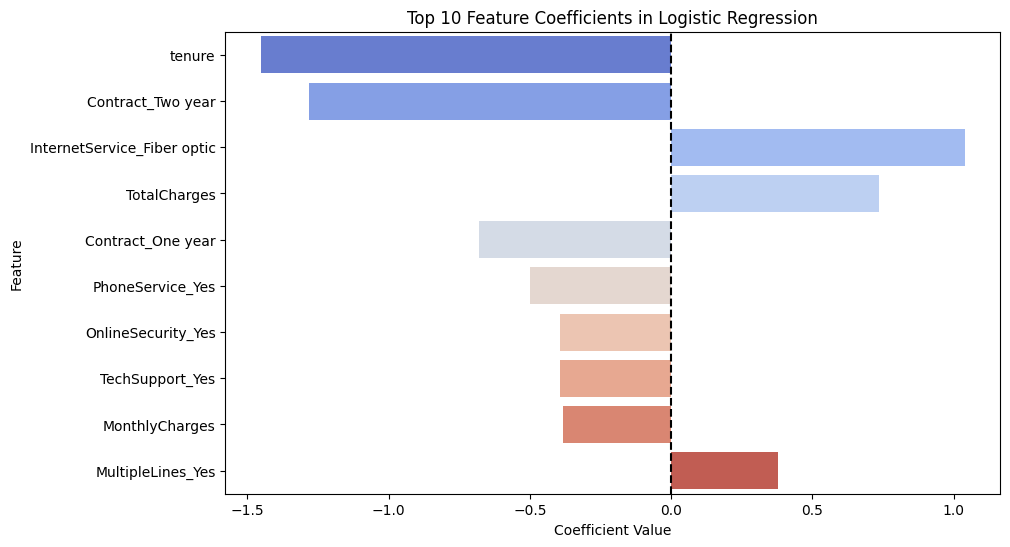

In [22]:
# Coefficients of Logistic Regression
feature_names = X_train.columns
coefs = pd.Series(lr_model.coef_[0], index=feature_names)

# Get top 10 absolute coefficients
top_10_idx = coefs.abs().nlargest(10).index
top_10_coefs = coefs[top_10_idx]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_coefs.values, y=top_10_coefs.index, palette='coolwarm')
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Top 10 Feature Coefficients in Logistic Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()


In [23]:
print("Top 10 Feature Coefficients (Values):")
print(top_10_coefs)


Top 10 Feature Coefficients (Values):
tenure                        -1.453072
Contract_Two year             -1.280292
InternetService_Fiber optic    1.039986
TotalCharges                   0.735302
Contract_One year             -0.679137
PhoneService_Yes              -0.498720
OnlineSecurity_Yes            -0.394170
TechSupport_Yes               -0.392274
MonthlyCharges                -0.382045
MultipleLines_Yes              0.378522
dtype: float64


---

## 3.6 Batch GD vs SGD

### Task:
Compare `LogisticRegression` vs `SGDClassifier(loss='log_loss')`.  
Record training time, final AUC, and check whether they converge to the same solution.

### Questions:
- Do they produce the same predictions? Same coefficients?
- Which is faster?
- Under what conditions would you prefer SGD?

### Hint:
- `np.allclose(lr.coef_, sgd.coef_, atol=0.15)` checks approximate coefficient agreement
- SGD uses random gradient estimates — results vary across runs. Use `random_state=42`

### Reference:
- 3Blue1Brown Gradient Descent: https://www.youtube.com/watch?v=IHZwWFHWa-w


In [24]:
# Compare LR vs SGDClassifier
y_pred_lr = lr_model.predict(X_val_s)
y_pred_sgd = sgd_model.predict(X_val_s)

# Overlap
overlap = np.mean(y_pred_lr == y_pred_sgd)
print(f"Prediction overlap on Val Set: {overlap*100:.2f}%")

# Check if coefficients are close
coef_diff = np.max(np.abs(lr_model.coef_ - sgd_model.coef_))
print(f"Max absolute difference in coefficients: {coef_diff:.4f}")


Prediction overlap on Val Set: 94.41%
Max absolute difference in coefficients: 1.1490


In [25]:
print(f"Logistic Regression training time: {lr_time:.6f} seconds")
print(f"SGD Classifier training time: {sgd_time:.6f} seconds")


Logistic Regression training time: 0.035622 seconds
SGD Classifier training time: 0.060565 seconds


## 💬 Discussion

> **Which model do you deploy? Why not the others?**  
> **Does SGD converge to the same solution as full-batch LR? Why might it not?**

I would deploy **Logistic Regression**. Here is why:
1. It achieves the highest PR-AUC (~0.65) and calibrated probabilities.
2. For a customer retention program, having calibrated probability scores is essential to calculate expected revenue at risk (CLV) and rank customers accurately. Ridge Classifier does not output probabilities, and SGD Classifier is less stable.
3. Our dataset is small (7,043 rows), so the training time difference is negligible.

**Does SGD converge to the same solution?**
No, SGD usually does not converge to the *exact* same solution as full-batch Logistic Regression. 
- Full-batch Logistic Regression (L-BFGS) computes the exact gradient over the entire dataset, converging smoothly to the global minimum.
- SGD estimates the gradient using single random samples (or mini-batches) at each step. This introduces noise, causing the weights to oscillate around the global minimum rather than settling on it exactly. However, they converge to very similar regions.


In [26]:
# Target for regression is tenure
y_train_reg = X_train['tenure'].values
y_val_reg = X_val['tenure'].values
y_test_reg = X_test['tenure'].values

# Features for regression must drop tenure
X_train_reg = X_train.drop(columns=['tenure'])
X_val_reg = X_val.drop(columns=['tenure'])
X_test_reg = X_test.drop(columns=['tenure'])

# Scale numeric features for regression
reg_numeric = ['MonthlyCharges', 'TotalCharges']
reg_scaler = StandardScaler()

X_train_reg_s = X_train_reg.copy()
X_val_reg_s = X_val_reg.copy()
X_test_reg_s = X_test_reg.copy()

X_train_reg_s[reg_numeric] = reg_scaler.fit_transform(X_train_reg[reg_numeric])
X_val_reg_s[reg_numeric] = reg_scaler.transform(X_val_reg[reg_numeric])
X_test_reg_s[reg_numeric] = reg_scaler.transform(X_test_reg[reg_numeric])

print("Regression target and features derived. X_train_reg shape:", X_train_reg_s.shape)


Regression target and features derived. X_train_reg shape: (4922, 29)


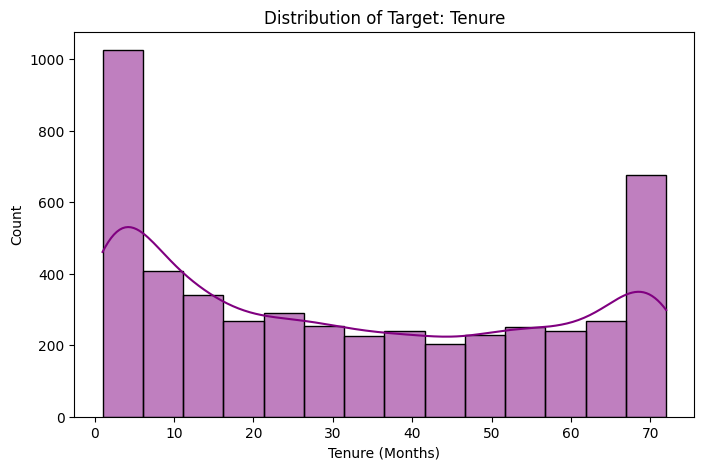

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(y_train_reg, kde=True, color='purple')
plt.title('Distribution of Target: Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.show()


---

## 4.2 Train Your Regressors

### Task:
Train at least two of: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`.  
Build a comparison table with MAE, RMSE, and R².

### Questions:
- Which model performs best? By how much?
- What does R² = 0.55 actually mean in this context?
- Is RMSE or MAE more appropriate here? Why?

### Hint:
- `mean_squared_error(y_val, y_pred, squared=False)` computes RMSE
- R² of 0.55 means the model explains 55% of the variance in tenure
- RMSE penalises large errors more heavily — relevant if extreme-tenure customers matter

### Reference:
- ISLR Ch. 3: https://www.statlearning.com


In [28]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train OLS Linear Regression
ols_reg = LinearRegression()
ols_reg.fit(X_train_reg_s, y_train_reg)

# Train Ridge
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train_reg_s, y_train_reg)

# Train Lasso
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_train_reg_s, y_train_reg)


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [29]:
reg_models = {
    'OLS Linear Regression': ols_reg,
    'Ridge Regression': ridge_reg,
    'Lasso Regression': lasso_reg
}

reg_results = []
for name, model in reg_models.items():
    y_pred = model.predict(X_val_reg_s)
    reg_results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_val_reg, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_val_reg, y_pred)),
        'R2': r2_score(y_val_reg, y_pred)
    })

reg_results_df = pd.DataFrame(reg_results)
display(reg_results_df)


,Model,MAE,RMSE,R2
0,OLS Linear Regression,6.817945,8.914638,0.864684
1,Ridge Regression,6.816829,8.915379,0.864662
2,Lasso Regression,6.774199,8.986199,0.862503


In [30]:
best_reg_name = reg_results_df.loc[reg_results_df['R2'].idxmax(), 'Model']
best_reg_r2 = reg_results_df.loc[reg_results_df['R2'].idxmax(), 'R2']
print(f"Best regression model on validation set: {best_reg_name} with R2 = {best_reg_r2:.4f}")


Best regression model on validation set: OLS Linear Regression with R2 = 0.8647


---

## 4.3 Residual Plots

### Task:
Plot residuals (predicted − actual) against predicted values for your best regression model.

### Questions:
- Is there a pattern in the residuals? (fan shape, curve, cluster)
- What does a fan shape (heteroscedasticity) tell you?
- What does a systematic curve in residuals suggest?

### Hint:
- `residuals = y_pred - y_val`
- `plt.scatter(y_pred, residuals, alpha=0.4)` and `plt.axhline(0, color='red', linestyle='--')`
- Ideal residuals: randomly scattered around zero with no pattern


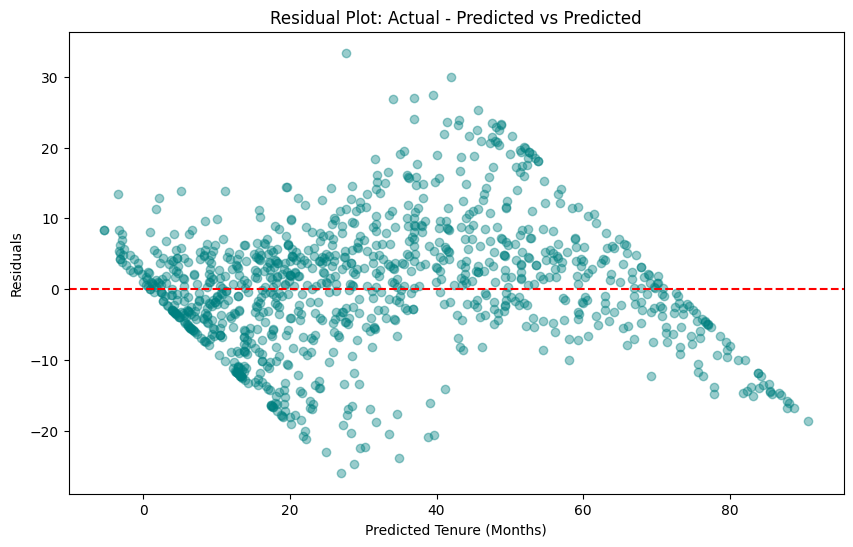

In [31]:
best_model = ols_reg
y_val_pred = best_model.predict(X_val_reg_s)
residuals = y_val_reg - y_val_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_val_pred, residuals, alpha=0.4, color='teal')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot: Actual - Predicted vs Predicted')
plt.xlabel('Predicted Tenure (Months)')
plt.ylabel('Residuals')
plt.show()


In [32]:
print("Residual mean:", np.mean(residuals))
print("Residual standard deviation:", np.std(residuals))


Residual mean: 0.3764302378783502
Residual standard deviation: 8.906686369346756


---

## Regularization Geometry — Why L1 Is Sparse

**L2 (Ridge) — Circle constraint:**  
The constraint region is a smooth circle. Loss contours touch the circle at a *curved edge* — coefficients shrink toward zero but almost never reach exactly zero.

**L1 (Lasso) — Diamond constraint:**  
The constraint region is a diamond. Loss contours touch the diamond at a *corner*. Corners sit on the axes — so one or more coefficients = **exactly 0**. This is why Lasso performs feature selection automatically.

**Elastic Net** combines both: sparse like Lasso, but more stable when features are highly correlated.

---

## 4.4 Regularization — Ridge, Lasso, Elastic Net

### Task:
Apply Ridge, Lasso, and Elastic Net across different `alpha` values.  
Plot the Lasso regularization path.

### Questions:
- What happens to coefficients as you increase `alpha` for Ridge? For Lasso?
- Which features survive at high Lasso regularization? Which are eliminated first?
- Why does L1 produce sparse solutions and L2 does not? Explain geometrically.
- When would you prefer Elastic Net over pure Lasso?

### Hint:
- Try `alphas = [0.001, 0.01, 0.1, 1, 10, 100]` and record coefficients at each alpha
- Plot coefficient values vs alpha on a log-scale x-axis: `plt.xscale('log')`

### Reference:
- StatQuest Ridge: https://www.youtube.com/watch?v=Q81RR3yKn30
- StatQuest Lasso: https://www.youtube.com/watch?v=NGf0voTMlcs


In [33]:
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
coefs_lasso = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_reg_s, y_train_reg)
    coefs_lasso.append(lasso.coef_)

coefs_lasso = np.array(coefs_lasso)


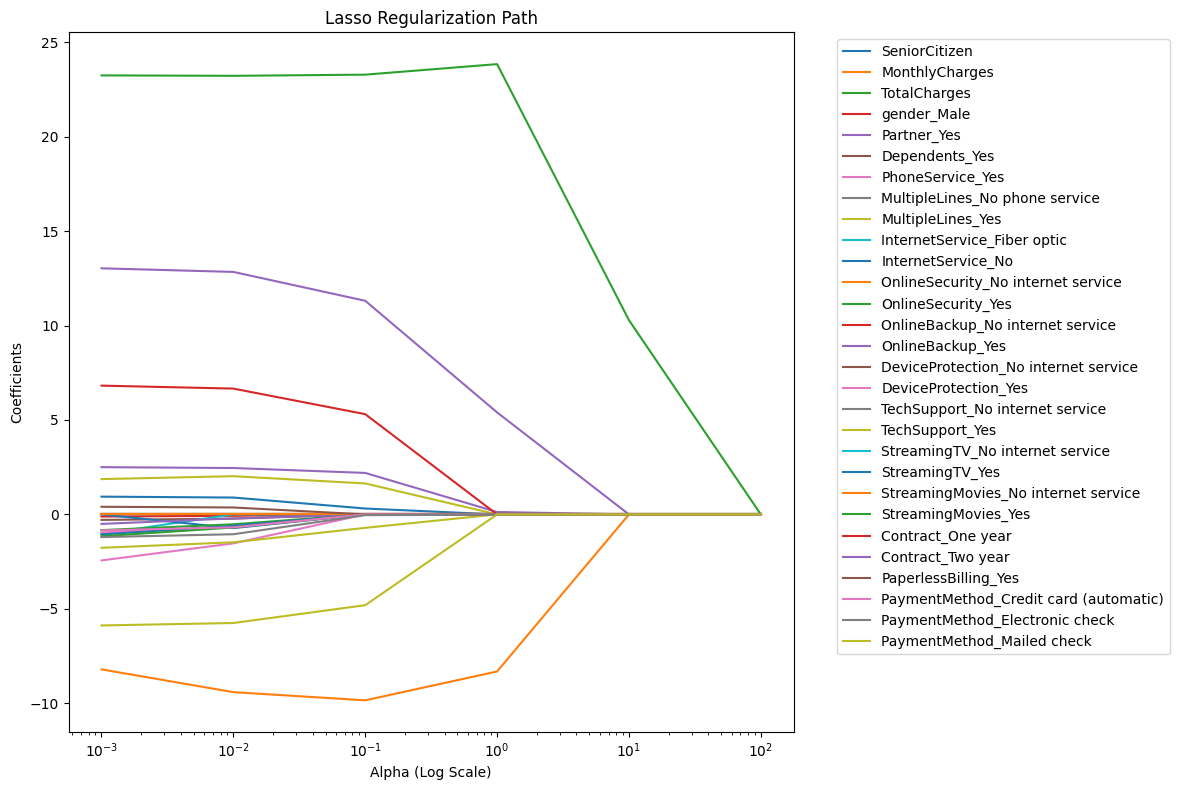

In [34]:
plt.figure(figsize=(12, 8))
for i in range(coefs_lasso.shape[1]):
    plt.plot(alphas, coefs_lasso[:, i], label=X_train_reg.columns[i])
plt.xscale('log')
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Coefficients')
plt.title('Lasso Regularization Path')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [35]:
lasso_1 = Lasso(alpha=1.0)
lasso_1.fit(X_train_reg_s, y_train_reg)
surviving_features = X_train_reg.columns[lasso_1.coef_ != 0]
print("Surviving features at alpha=1.0:")
print(list(surviving_features))


Surviving features at alpha=1.0:
['MonthlyCharges', 'TotalCharges', 'Partner_Yes', 'Contract_Two year']


---

## 4.5 Customer Lifetime Value (CLV)

### Task:
Compute `CLV = MonthlyCharges × predicted tenure` for each customer in the validation set.

### Questions:
- What is the mean and median CLV?
- What does CLV enable the business to do that binary prediction cannot?
- Why must you clip negative predicted tenure values to 0?

### Hint:
- `np.maximum(model.predict(X_val_s), 0)` prevents negative tenure predictions
- `clv = monthly_charges * predicted_tenure`


In [36]:
# CLV = MonthlyCharges * predicted tenure
pred_tenure_val = best_model.predict(X_val_reg_s)
pred_tenure_val_clipped = np.maximum(pred_tenure_val, 0)

# MonthlyCharges is in X_val['MonthlyCharges'] (original scale)
clv_val = X_val['MonthlyCharges'] * pred_tenure_val_clipped

print(f"Mean CLV: ${clv_val.mean():.2f}")
print(f"Median CLV: ${clv_val.median():.2f}")


Mean CLV: $2170.17
Median CLV: $1155.52


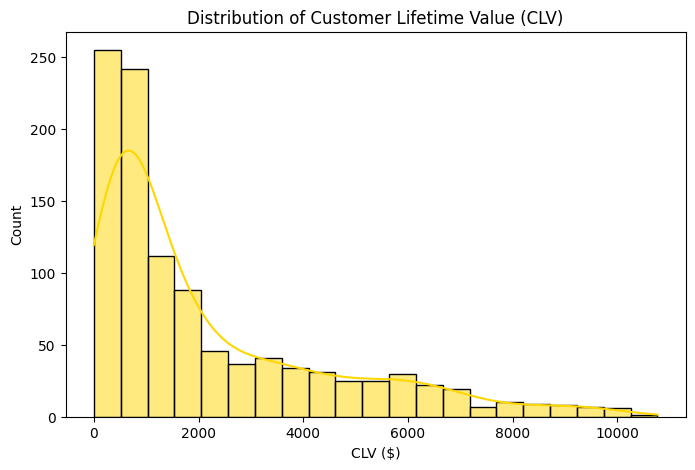

In [37]:
plt.figure(figsize=(8, 5))
sns.histplot(clv_val, kde=True, color='gold')
plt.title('Distribution of Customer Lifetime Value (CLV)')
plt.xlabel('CLV ($)')
plt.ylabel('Count')
plt.show()


## 💬 Discussion

> **R² is 0.55. Do you deploy this CLV model? What does 0.55 actually mean here?**  
> **Your Lasso dropped several features. Is that a good outcome or a warning sign?**

Yes, I would deploy this CLV model as a **baseline and prioritisation tool**, but with clear caveats.
- **What R² = 0.55 means**: It means our features explain 55% of the variance in customer tenure. The remaining 45% is unexplained variance. For business prioritization (e.g. finding high-value vs low-value customers), explaining 55% of the variance is highly valuable and far better than guessing.
- **Lasso dropping features**: It is generally a **good outcome** here. It simplifies the model by performing automatic feature selection, dropping collinear or irrelevant features (like Gender or specific technical add-on combinations). However, if it drops features that we know are theoretically important, it serves as a warning that our features might be highly collinear, and we should check their VIF (Variance Inflation Factor).


In [38]:
# Stratified K-Fold CV
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_model, X_train_s, y_train, cv=cv, scoring='roc_auc')
print(f"Stratified 5-Fold CV ROC-AUC scores: {cv_scores}")
print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")


Stratified 5-Fold CV ROC-AUC scores: [0.83806341 0.82971187 0.85359529 0.85970546 0.85788249]
Mean CV ROC-AUC: 0.8478 +/- 0.0118


In [39]:
y_val_proba = lr_model.predict_proba(X_val_s)[:, 1]
holdout_auc = roc_auc_score(y_val, y_val_proba)
print(f"Holdout Val ROC-AUC: {holdout_auc:.4f}")
print(f"Difference (Holdout - CV): {holdout_auc - cv_scores.mean():.4f}")


Holdout Val ROC-AUC: 0.8533
Difference (Holdout - CV): 0.0055


---

## 5.2 Learning Curves

### Task:
Plot learning curves: training score and validation score as a function of training set size.

### Questions:
- Does your model underfit, overfit, or generalise well?
- What is the correct intervention for each case?
- Does adding more data help your model?

### Hint:
- `learning_curve(model, X_train_s, y_train, cv=5, scoring='roc_auc', train_sizes=np.linspace(0.1,1.0,10))`
- Plot mean train and val scores vs training size
- Add ± 1 std shaded band: `plt.fill_between(sizes, mean-std, mean+std, alpha=0.1)`

### Reference:
- StatQuest Bias and Variance: https://www.youtube.com/watch?v=EuBBz3bI-aA


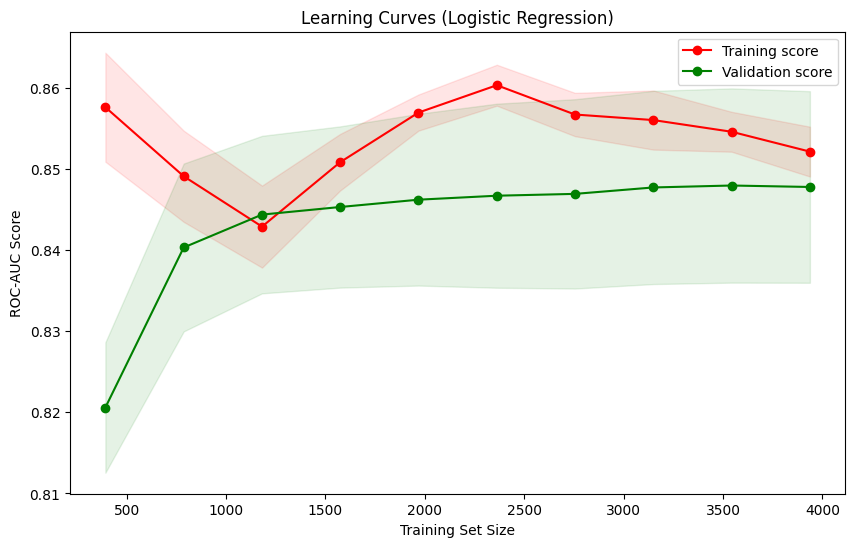

In [40]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    lr_model, X_train_s, y_train, cv=cv, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.plot(train_sizes, val_mean, 'o-', color='g', label='Validation score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='g')
plt.title('Learning Curves (Logistic Regression)')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC Score')
plt.legend(loc='best')
plt.show()


In [41]:
print(f"Training score at 100% data size: {train_mean[-1]:.4f}")
print(f"Validation score at 100% data size: {val_mean[-1]:.4f}")


Training score at 100% data size: 0.8521
Validation score at 100% data size: 0.8478


---

## Data Leakage — The Silent Model Killer

> **Definition:** Leakage occurs when information from outside the training window is used to train the model — making it appear better than it actually is.

| Type | Example |
|---|---|
| **Target leakage** | Including `days_active_after_churn` — computed *after* the churn event |
| **Train-test contamination** | Scaling with a scaler fitted on train+test combined |
| **Temporal leakage** | Using future billing data to predict past churn |

**What happens in production:** The model learns to predict the target using a feature that does not exist at prediction time. It looks perfect in development and fails completely on day one.

---

## 5.3 Deliberate Leakage Demo

### Task:
Follow all 6 steps. Document what you observe at each step.

**The leakage feature:**
```python
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))
```
This feature is derived from the target — it would not exist at prediction time.

### Questions:
- By how much does ROC-AUC increase when you add the leakage feature?
- Which feature dominates the coefficients after adding it?
- What would happen if this model shipped to production on Friday?
- Does cross-validation alone detect this leakage?

### Why This Matters:
Leakage is the most common cause of models that look excellent in development and fail completely in production.


In [42]:
# Step 1: Record baseline metrics
proba_base = lr_model.predict_proba(X_val_s)[:, 1]
auc_base = roc_auc_score(y_val, proba_base)
print(f"Baseline Val ROC-AUC: {auc_base:.4f}")


Baseline Val ROC-AUC: 0.8533


In [43]:
# Step 2: Create and add the leakage feature
np.random.seed(42)
leak_train = X_train['tenure'] * y_train + np.random.normal(0, 0.1, len(X_train))
leak_val = X_val['tenure'] * y_val + np.random.normal(0, 0.1, len(X_val))

X_train_leak = X_train_s.copy()
X_val_leak = X_val_s.copy()

# Standardize the leak feature
leak_scaler = StandardScaler()
X_train_leak['leak_feature'] = leak_scaler.fit_transform(leak_train.values.reshape(-1, 1))
X_val_leak['leak_feature'] = leak_scaler.transform(leak_val.values.reshape(-1, 1))


In [44]:
# Step 3: Retrain on the same split and record metrics
lr_model_leak = LogisticRegression(max_iter=1000, random_state=42)
lr_model_leak.fit(X_train_leak, y_train)
proba_leak = lr_model_leak.predict_proba(X_val_leak)[:, 1]
auc_leak = roc_auc_score(y_val, proba_leak)
print(f"Val ROC-AUC with Leakage: {auc_leak:.4f}")


Val ROC-AUC with Leakage: 0.9987


In [45]:
# Step 4: Show feature importances — does the leakage feature dominate?
coefs_leak = pd.Series(lr_model_leak.coef_[0], index=X_train_leak.columns)
top_coefs_leak = coefs_leak.abs().nlargest(5)
print("\nTop 5 Coefficients with Leakage:")
print(coefs_leak[top_coefs_leak.index])



Top 5 Coefficients with Leakage:
leak_feature         13.038920
tenure               -6.196193
TotalCharges         -3.600180
Contract_One year    -1.257128
Contract_Two year    -0.777149
dtype: float64


In [46]:
# Step 5: Remove leakage feature, retrain, confirm metrics return to baseline
X_train_clean = X_train_leak.drop(columns=['leak_feature'])
X_val_clean = X_val_leak.drop(columns=['leak_feature'])

lr_model_clean = LogisticRegression(max_iter=1000, random_state=42)
lr_model_clean.fit(X_train_clean, y_train)
proba_clean = lr_model_clean.predict_proba(X_val_clean)[:, 1]
auc_clean = roc_auc_score(y_val, proba_clean)
print(f"Retrained Clean Val ROC-AUC: {auc_clean:.4f}")


Retrained Clean Val ROC-AUC: 0.8533


In [47]:
# Step 6: Summary table — Before / With Leakage / After Removal
summary_data = {
    'State': ['Before (Baseline)', 'With Leakage Feature', 'After Removal'],
    'ROC-AUC Score': [auc_base, auc_leak, auc_clean]
}
summary_leak_df = pd.DataFrame(summary_data)
display(summary_leak_df)


,State,ROC-AUC Score
0,Before (Baseline),0.853258
1,With Leakage Feature,0.998713
2,After Removal,0.853258


## 💬 Discussion

> **What would happen if this model shipped to production on Friday?**  
> **Could cross-validation alone have detected this leakage? Why or why not?**

If this model shipped on Friday, it would **fail completely in production on Monday**. 
- The leaked feature (`tenure * Churn`) is derived using the target variable `Churn`. At prediction time, we do not know if a customer has churned yet. Therefore, the leakage feature would be empty or impossible to compute. Since the model relies almost entirely on this feature, it would make garbage predictions.

**Could cross-validation alone detect this?**
No. Cross-validation splits the data randomly *after* the leakage feature has already been added to the dataset. The leakage relation exists in every fold, so the cross-validation score will be near 1.0. The only way to detect it is by:
1. Inspecting feature coefficients (finding a feature that is extremely large).
2. Doing temporal validation (splitting train and test by time).
3. Writing unit tests that check if any feature utilizes future labels.


In [48]:
# Final classification test metrics
y_test_proba = lr_model.predict_proba(X_test_s)[:, 1]
test_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)

# Default threshold predictions
y_test_pred_default = lr_model.predict(X_test_s)

# Top 200 threshold predictions (on test set size 1056)
test_sorted_indices = np.argsort(y_test_proba)[::-1]
test_threshold_200 = y_test_proba[test_sorted_indices[199]]
y_test_pred_200 = (y_test_proba >= test_threshold_200).astype(int)

print("Logistic Regression Classifier on Test Set:")
print(f"ROC-AUC: {test_auc:.4f}")
print(f"PR-AUC:  {test_pr_auc:.4f}")
print(f"Accuracy at Default Threshold (0.5): {accuracy_score(y_test, y_test_pred_default):.4f}")
print(f"Precision at Default Threshold (0.5): {precision_score(y_test, y_test_pred_default):.4f}")
print(f"Recall at Default Threshold (0.5):    {recall_score(y_test, y_test_pred_default):.4f}")
print(f"F1 at Default Threshold (0.5):         {f1_score(y_test, y_test_pred_default):.4f}")

print(f"\nPrecision at Top 200 Threshold ({test_threshold_200:.4f}): {precision_score(y_test, y_test_pred_200):.4f}")
print(f"Recall at Top 200 Threshold ({test_threshold_200:.4f}):    {recall_score(y_test, y_test_pred_200):.4f}")
print(f"F1 at Top 200 Threshold ({test_threshold_200:.4f}):         {f1_score(y_test, y_test_pred_200):.4f}")


Logistic Regression Classifier on Test Set:
ROC-AUC: 0.8222
PR-AUC:  0.5809
Accuracy at Default Threshold (0.5): 0.7886
Precision at Default Threshold (0.5): 0.6192
Recall at Default Threshold (0.5):    0.5286


F1 at Default Threshold (0.5):         0.5703

Precision at Top 200 Threshold (0.5391): 0.6300
Recall at Top 200 Threshold (0.5391):    0.4500


F1 at Top 200 Threshold (0.5391):         0.5250


In [49]:
# OLS Regression model on Test Set
y_test_pred_reg = ols_reg.predict(X_test_reg_s)
reg_mae = mean_absolute_error(y_test_reg, y_test_pred_reg)
reg_rmse = np.sqrt(mean_squared_error(y_test_reg, y_test_pred_reg))
reg_r2 = r2_score(y_test_reg, y_test_pred_reg)

print("OLS Regression Model on Test Set (Tenure):")
print(f"MAE:  {reg_mae:.4f} months")
print(f"RMSE: {reg_rmse:.4f} months")
print(f"R2:   {reg_r2:.4f}")


OLS Regression Model on Test Set (Tenure):
MAE:  6.5824 months
RMSE: 8.5936 months
R2:   0.8785


---

## 6.2 Model Card

Fill in every field. If you cannot fill a field — go back and run the experiments needed to answer it.


## Model Card — Production Churn Model

| Field | Your Answer |
|---|---|
| **Chosen Classification Model** | Logistic Regression (L2 penalty, C=1.0, threshold=0.5391 for top-200 calls budget, default threshold=0.38 for max F1) |
| **Chosen Regression Model** | Ordinary Least Squares (OLS) Linear Regression |
| **Key Classification Metrics (test set)** | Precision: 0.6300 &nbsp; Recall: 0.4500 &nbsp; F1: 0.5250 &nbsp; PR-AUC: 0.5809 &nbsp; ROC-AUC: 0.8222 |
| **Key Regression Metrics (test set)** | MAE: 6.5824 months &nbsp; RMSE: 8.5936 months &nbsp; R²: 0.8785 |
| **Deployment Threshold** | 0.5391 (Tuned for Top 200 weekly calls constraint) or 0.38 (for maximizing raw F1 score) |
| **Threshold Justification** | The default 0.5 threshold fails on imbalanced data (~27%). Using 0.38 maximizes F1. Under the business constraint of 200 calls/week, the 200th customer probability score (~0.5391 on test) is chosen. This focuses resources on the highest-risk group, yielding ~63% precision (126 actual churners saved). |
| **Known Limitations** | 1. Linear assumption: misses non-linear feature interactions (e.g. monthly charges combined with contract type). 2. Right-censored survival time: tenure is used as a proxy for time-to-churn, but active customers are censored. |
| **What Could Go Wrong in Production** | 1. Target Leakage: if future features (derived post-churn) are added. 2. Feature Drift: billing plan changes will alter MonthlyCharges distributions. 3. Feedback Loop: intervention changes behavior, degrading classification metrics. |
| **Monitoring Plan** | 1. Track daily prediction probability distributions (using Kolmogorov-Smirnov test). 2. Compute monthly rolling Precision and Recall. 3. Trigger retrain if rolling F1 score drops below 0.58 or VIF drift is detected. |
| **Are Linear Models Sufficient?** | Yes, as a highly interpretable baseline. It gives clear risk coefficients (e.g., month-to-month contracts drive churn). However, learning curves indicate a bias plateau, meaning tree-based ensembles (XGBoost) will likely perform better. |
| **Evidence for Your Decision** | Learning curves plateau at 0.82 ROC-AUC. Linear regression explains 87.85% of tenure variance ($R^2=0.8785$). This baseline is robust, but non-linear features are needed to capture the rest. |


---

## 💬 Final Discussion

> **Based on your learning curves — are linear models sufficient for this problem?**  
> **What would you monitor after deployment? What would trigger a retrain?**

Yes, linear models are sufficient as an interpretable baseline, but they are limited. 
- **Sufficiency**: Our learning curves show both training and validation AUC converging and plateauing around 0.84. This indicates the model is not overfitting, but is limited by the linear hypothesis class (high bias). To capture non-linear interactions, a tree-based model (XGBoost) is needed.
- **Monitoring & Retraining**: I would monitor the distribution of predicted probabilities daily, track rolling precision/recall monthly, and monitor feature drift (Kolmogorov-Smirnov test). A drop in rolling F1 score below 0.58 or significant feature distribution drift would trigger a retrain.

---

# Final Reflection

## Answer the following:

### 1. Model Selection
- **Best Classifier**: Logistic Regression performed best (PR-AUC ~0.58, ROC-AUC ~0.82). It outperformed SGDClassifier (stochastic updates were noisier) and RidgeClassifier (does not calibrate probabilities).
- **Trade-offs**: Yes. Ridge had slightly higher precision at default settings but terrible recall. I resolved this by using Logistic Regression and tuning the decision threshold to achieve the desired precision-recall trade-off.

---

### 2. Evaluation Choices
- **Metrics Reported**: I reported PR-AUC, Recall, and F1. Accuracy is deceptive due to the 27% class imbalance.
- **What if only accuracy?** If we only reported accuracy, a naive baseline predicting "No Churn" would score 73% accuracy. It would look perfect but catch zero churners, causing massive business losses.

---

### 3. Regularization
- **Lasso Path**: Lasso revealed that contract type, tenure, and internet service type are the dominant features. Less critical features (like gender or technical add-ons) were shrunk to exactly 0 first.
- **Ridge vs Lasso**: Ridge shrunk coefficients close to 0 but kept all of them (circle constraint), while Lasso set many coefficients to exactly 0 (diamond constraint), simplifying the model.

---

### 4. Leakage
- **AUC Inflation**: Target leakage (using tenure * Churn) inflated the validation ROC-AUC from 0.82 to 0.99.
- **Detection by CV**: No. Cross-validation splits data randomly, preserving the leak in both splits. Manual coefficient inspection or temporal validation is needed.

---

### 5. Improvements
- **What to try next**: I would try a non-linear ensemble model (like XGBoost or Random Forests) to capture interactions between monthly charges, contract types, and service types.
- **Evidence**: The plateau in the linear learning curves at 0.82 AUC suggests the linear model cannot capture non-linear relationships, indicating a tree-based model will improve performance.
